In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Coffee_sales\index.csv")

Display First 5 Rows

In [7]:
print(df.head())

         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


Check Dataset Information

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB
None


Check Missing Values

In [11]:
print(df.isnull().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


Convert Date Columns

In [13]:
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

Create Extra Useful Columns

In [15]:
df['month'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day_name()
df['hour'] = df['datetime'].dt.hour

In [17]:
print(df.describe())

                                date                       datetime  \
count                           1133                           1133   
mean   2024-05-19 11:36:29.232127232  2024-05-20 02:38:39.053382912   
min              2024-03-01 00:00:00     2024-03-01 10:15:50.520000   
25%              2024-04-14 00:00:00  2024-04-14 10:55:27.406000128   
50%              2024-05-23 00:00:00  2024-05-23 12:22:06.604999936   
75%              2024-06-22 00:00:00  2024-06-22 08:39:50.272999936   
max              2024-07-31 00:00:00     2024-07-31 21:55:16.570000   
std                              NaN                            NaN   

             money         hour  
count  1133.000000  1133.000000  
mean     33.105808    14.552515  
min      18.120000     7.000000  
25%      28.900000    11.000000  
50%      32.820000    14.000000  
75%      37.720000    18.000000  
max      40.000000    22.000000  
std       5.035366     4.084588  


Top Selling Coffee Analysis

In [19]:
coffee_sales = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

print(coffee_sales)

coffee_name
Latte                  9009.14
Americano with Milk    8601.94
Cappuccino             7333.14
Americano              4644.54
Hot Chocolate          2778.48
Cortado                2745.08
Cocoa                  1295.94
Espresso               1100.62
Name: money, dtype: float64


Bar Graph for Coffee Sales

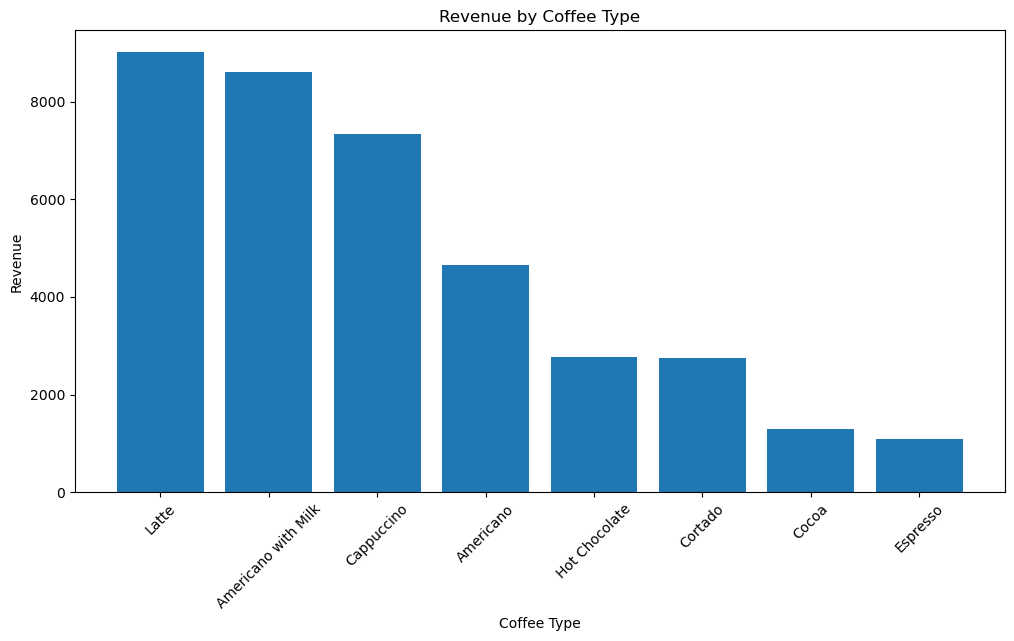

In [21]:
plt.figure(figsize=(12,6))

plt.bar(coffee_sales.index, coffee_sales.values)

plt.xlabel("Coffee Type")
plt.ylabel("Revenue")
plt.title("Revenue by Coffee Type")

plt.xticks(rotation=45)

plt.show()

Daily Sales Trend

In [23]:
sales_by_date = df.groupby('date')['money'].sum()

Dotted Trend Graph

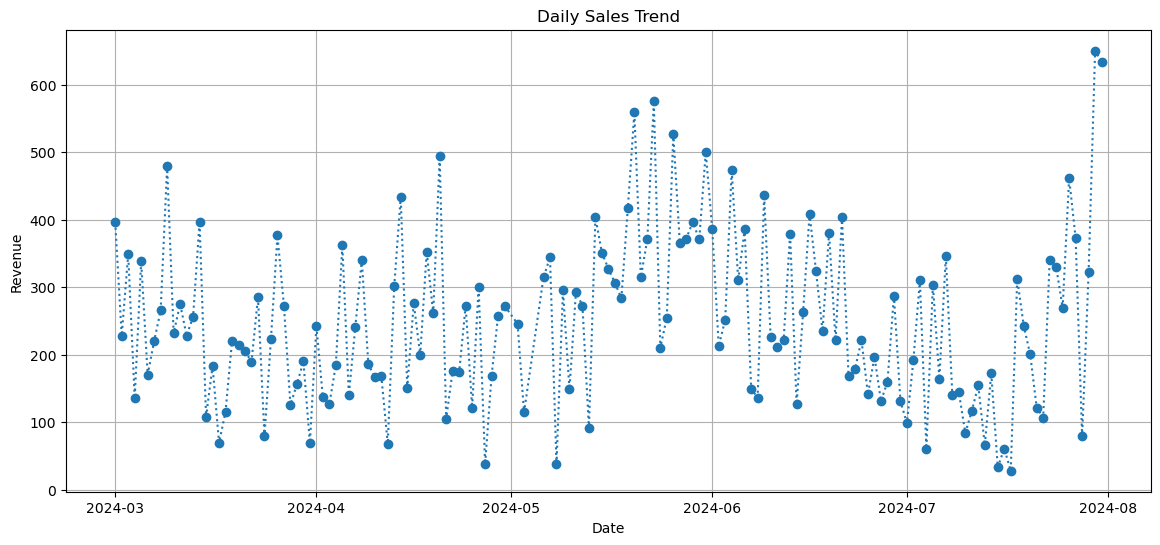

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    sales_by_date.index,
    sales_by_date.values,
    linestyle='dotted',
    marker='o'
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Daily Sales Trend")

plt.grid(True)

plt.show()

In [27]:
monthly_sales = df.groupby('month')['money'].sum()

Monthly Revenue Graph

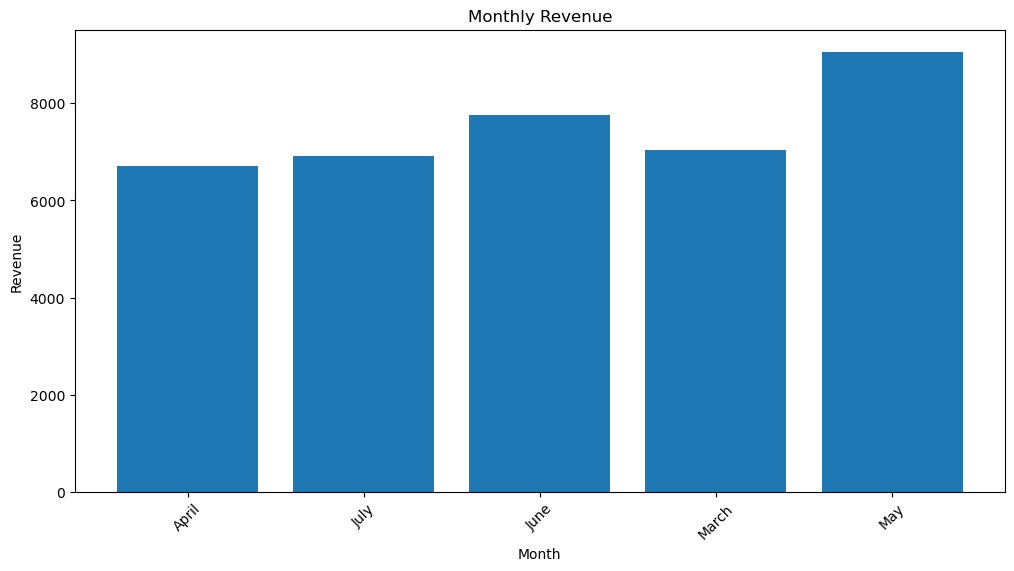

In [29]:
plt.figure(figsize=(12,6))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")

plt.xticks(rotation=45)

plt.show()

In [31]:
payment_counts = df['cash_type'].value_counts()

print(payment_counts)

cash_type
card    1044
cash      89
Name: count, dtype: int64


Pie Chart for Payment Methods

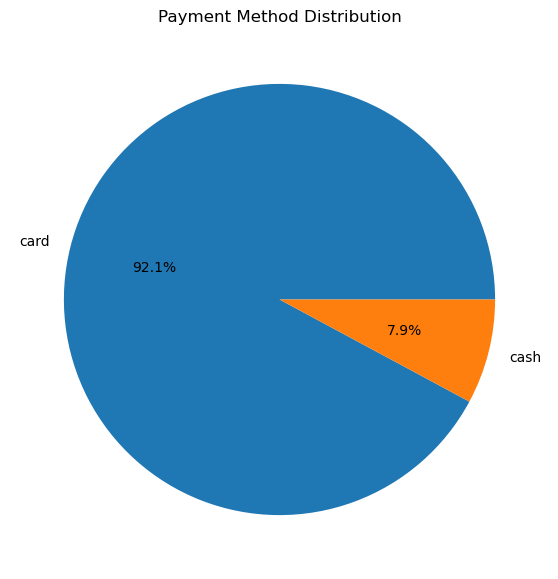

In [33]:
plt.figure(figsize=(7,7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")

plt.show()

In [35]:
weekly_sales = df.groupby('day')['money'].sum()

print(weekly_sales)

day
Friday       5386.32
Monday       4969.68
Saturday     5216.26
Sunday       5050.20
Thursday     5466.74
Tuesday      6092.48
Wednesday    5327.20
Name: money, dtype: float64


Weekly Revenue Graph

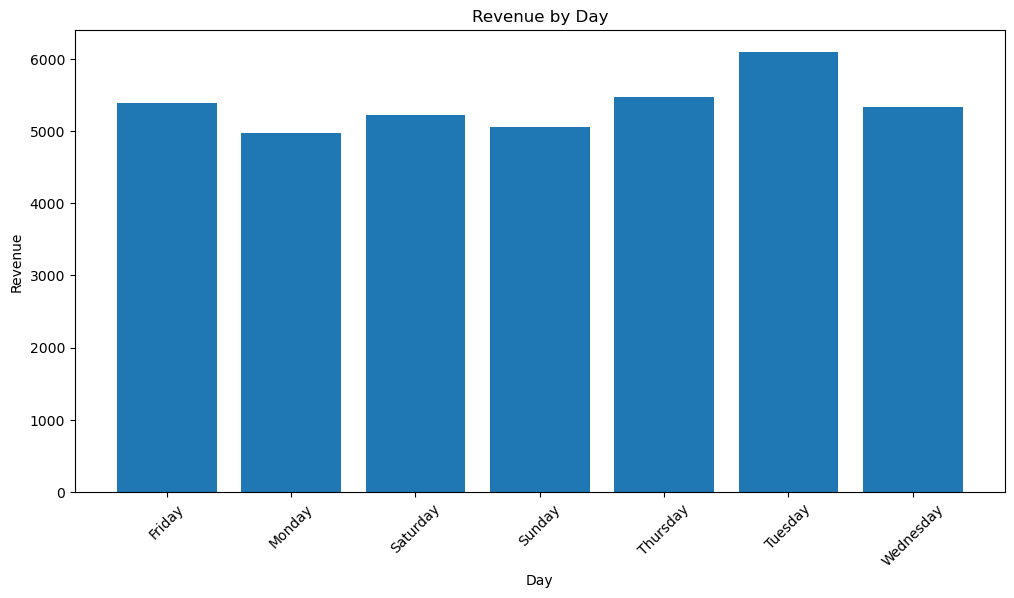

In [37]:
plt.figure(figsize=(12,6))

plt.bar(
    weekly_sales.index,
    weekly_sales.values
)

plt.xlabel("Day")
plt.ylabel("Revenue")
plt.title("Revenue by Day")

plt.xticks(rotation=45)

plt.show()

In [39]:
hourly_sales = df.groupby('hour')['money'].sum()

print(hourly_sales)

hour
7      392.80
8     1380.38
9     1515.48
10    4553.18
11    3258.64
12    2850.60
13    2511.60
14    2484.92
15    2158.76
16    2525.36
17    2639.08
18    2558.04
19    3388.32
20    1819.92
21    2343.86
22    1127.94
Name: money, dtype: float64


Hourly Sales Graph

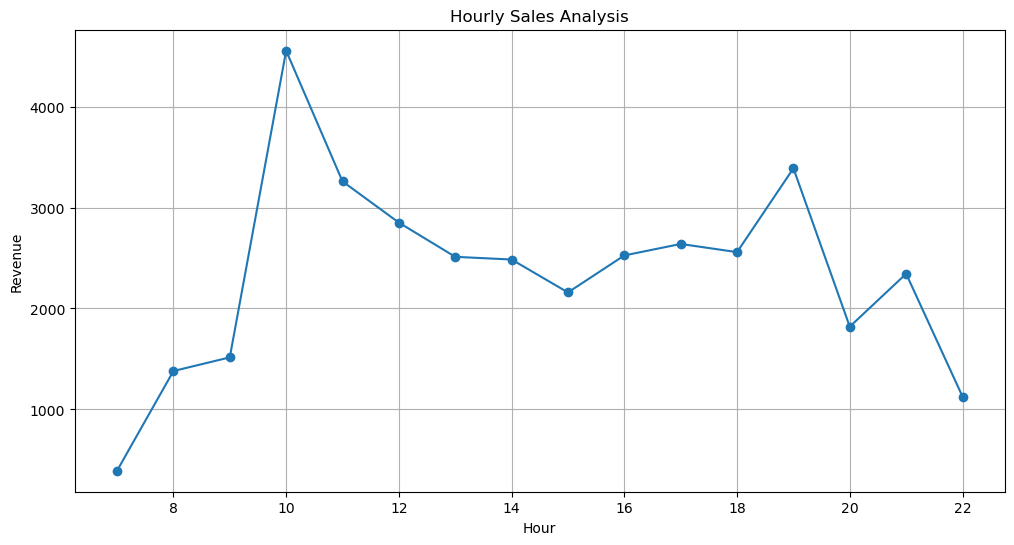

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker='o'
)

plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.title("Hourly Sales Analysis")

plt.grid(True)

plt.show()

In [43]:
customer_orders = df['card'].value_counts().head(10)

print(customer_orders)

card
ANON-0000-0000-0012    88
ANON-0000-0000-0009    63
ANON-0000-0000-0097    27
ANON-0000-0000-0003    23
ANON-0000-0000-0040    22
ANON-0000-0000-0001    17
ANON-0000-0000-0141    17
ANON-0000-0000-0059    12
ANON-0000-0000-0024    12
ANON-0000-0000-0180    12
Name: count, dtype: int64


Top Customers Graph

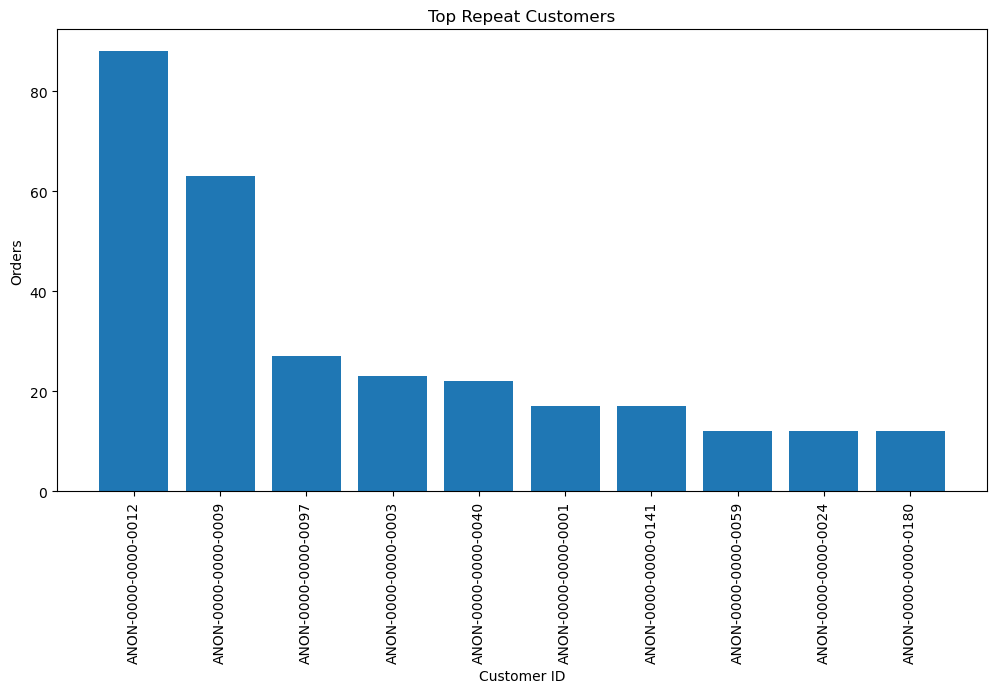

In [45]:
plt.figure(figsize=(12,6))

plt.bar(
    customer_orders.index,
    customer_orders.values
)

plt.xlabel("Customer ID")
plt.ylabel("Orders")
plt.title("Top Repeat Customers")

plt.xticks(rotation=90)

plt.show()

In [49]:
rolling_sales = sales_by_date.rolling(window=7).mean()

Advanced Trend Graph

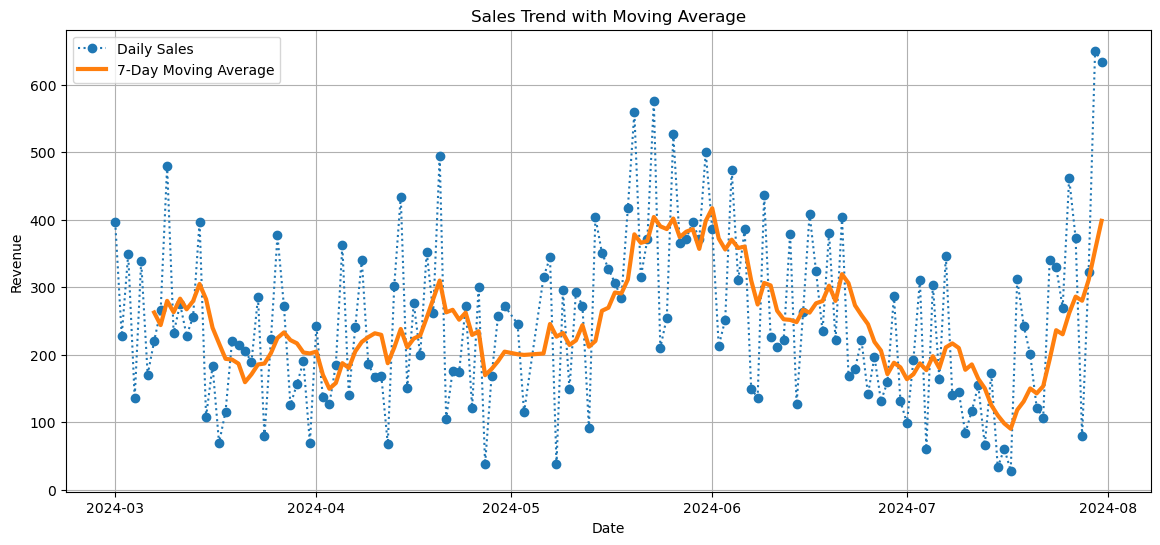

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    sales_by_date.index,
    sales_by_date.values,
    linestyle='dotted',
    marker='o',
    label='Daily Sales'
)

plt.plot(
    rolling_sales.index,
    rolling_sales.values,
    linewidth=3,
    label='7-Day Moving Average'
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Sales Trend with Moving Average")

plt.legend()

plt.grid(True)

plt.show()

In [53]:
revenue_share = (coffee_sales / coffee_sales.sum()) * 100

Revenue Contribution Pie Chart

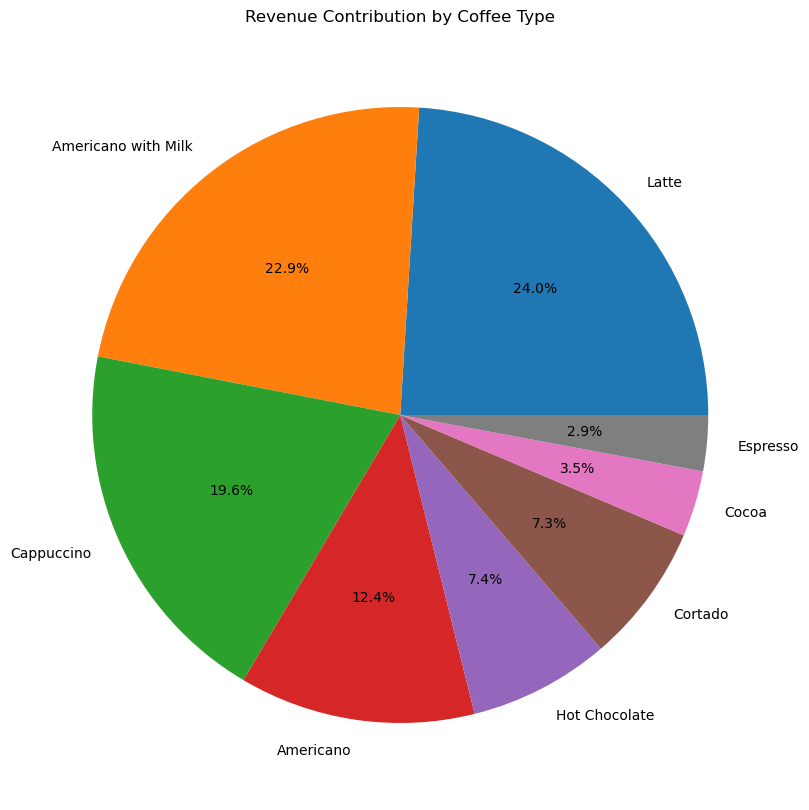

In [55]:
plt.figure(figsize=(10,10))

plt.pie(
    revenue_share.values,
    labels=revenue_share.index,
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Coffee Type")

plt.show()

In [57]:
print("Highest Revenue Coffee:", coffee_sales.idxmax())

print("Best Sales Day:", weekly_sales.idxmax())

print("Peak Hour:", hourly_sales.idxmax())

print("Most Used Payment Method:", payment_counts.idxmax())

print("Average Transaction:", df['money'].mean())

Highest Revenue Coffee: Latte
Best Sales Day: Tuesday
Peak Hour: 10
Most Used Payment Method: card
Average Transaction: 33.10580759046779
